In [1]:
import joblib
import cloudpickle
import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

import pymc as pm
import pymc_bart as pmb
import arviz as az
import arviz_plots as azp
import xarray as xr
from scipy.special import expit

import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from sklearn.calibration import calibration_curve

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)

In [2]:
print(pm.__version__)
print(pmb.__version__)

5.25.1
0.11.0


In [3]:
bart_mm_scaler = joblib.load('minmax_scaler.pkl')

In [4]:
df=pd.read_csv('input/data_model.csv')
df.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train,distance_mm,angle_mm
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,1,2022-23,1,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1,0.267300,0.670484
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,1,2022-23,1,Marcus Smart,203935.0,29.401780,76.0,G,2,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1,0.275325,0.653883
2,22200001,2,8,12,MISS Harris 14' Driving Floating Jump Shot,0,14.396180,20.323137,50,135,2,Driving Floating Jump Shot,3,JUMPER,1,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,0.0,2.0,-2.0,1,11.083333,665.0,0,1610612755,PHI,0,0.300267,0.203268
3,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,2,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1,0.000000,0.000000
4,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,1,2022-23,1,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1,0.494566,0.780882


In [5]:
bart_features = ['Shot Distance', 'Angle']
bart_train = df.loc[df['is_train']==1][['distance_mm','angle_mm']].values
bart_test = df.loc[df['is_train']!=1][['distance_mm','angle_mm']].values
target_train=df.loc[df['is_train']==1]['is_made'].values
target_test=df.loc[df['is_train']!=1]['is_made'].values

In [6]:
def sample(
    model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED
):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            random_seed=random_seed,
            cores=4,
            idata_kwargs={"log_likelihood": False}
        )
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [7]:
coords = {
        "bart_variables":np.array(bart_features),
        "obs_id": np.arange(len(target_train))
    }
with pm.Model(coords=coords) as model:
    # mutable data
    shot_made = pm.Data("shot_made", target_train, dims=("obs_id",))
    bart_data = pm.Data("bart_data", bart_train, dims=("obs_id", "bart_variables"))
    # Bart
    mu = pmb.BART("mu", X=bart_data, Y=shot_made, m=20, dims=("obs_id",))
    # likelihood
    shot_lkhood = pm.Bernoulli("shot_lkhood", logit_p=mu, observed=shot_made, dims=("obs_id",))

In [8]:
trace_bart = sample(model)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [mu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3473 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
#az.to_netcdf(trace_bart, "trace_bart.nc")

'trace_bart.nc'

In [ ]:
# with open("models_pkl/xs_model.pkl", "wb") as f:
#     cloudpickle.dump(model, f)

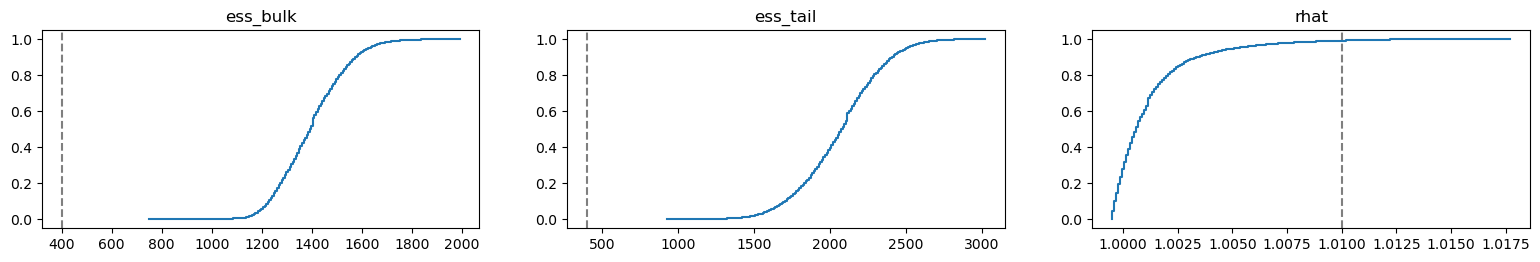

In [11]:
azp.plot_convergence_dist(trace_bart, var_names="mu")

In [12]:
dist_vals = np.arange(0, 54, 6) 
angle_vals = np.arange(0, 101, 5)

dist_vals_scaled = bart_mm_scaler.transform(np.c_[dist_vals, np.zeros_like(dist_vals)])[:, 0]
angle_vals_scaled = bart_mm_scaler.transform(np.c_[np.zeros_like(angle_vals), angle_vals])[:, 1]
q_list = np.linspace(0, 1, 50).tolist()

/home/jr/anaconda3/envs/pie/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/jr/anaconda3/envs/pie/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


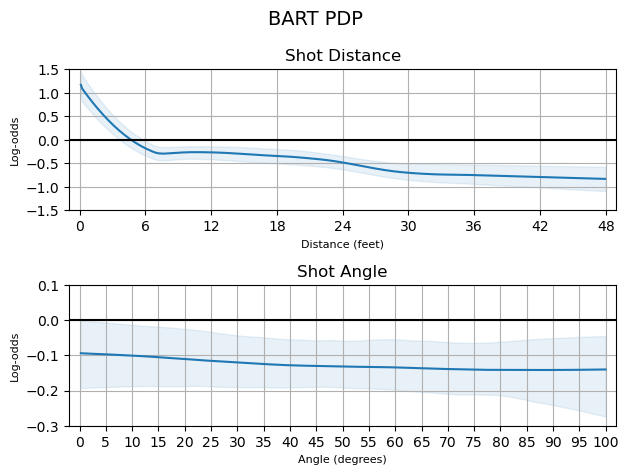

In [19]:
axes = pmb.plot_pdp(
    mu, 
    X=bart_train, 
    Y=target_train, 
    sharey=False, 
    xs_interval="quantiles", 
    xs_values=q_list
) 
ax_dist, ax_angle = axes[0], axes[1] 
fig = plt.gcf() 
fig.texts.clear() 
for ax in [ax_dist, ax_angle]:
    for line in ax.lines:
        if (line.get_linestyle() in ['--']):
            line.remove()

ax_dist.set_xticks(dist_vals_scaled) 
ax_dist.set_xticklabels([f"{v:.0f}" for v in dist_vals]) 
ax_dist.set_xlim(-0.02, max(dist_vals_scaled) + 0.02)
ax_dist.set_title("Shot Distance") 
ax_dist.set_xlabel("Distance (feet)", fontsize=8)
ax_dist.set_ylabel("Log-odds", fontsize=8)
ax_dist.set_ylim(-1.5, 1.5)
ax_dist.grid(True)
ax_dist.set_yticks(np.arange(-1.5, 2.0, 0.5)) 

ax_angle.set_xticks(angle_vals_scaled) 
ax_angle.set_xticklabels([f"{v:.0f}" for v in angle_vals]) 
ax_angle.set_xlim(-0.02, max(angle_vals_scaled) + 0.02) 
ax_angle.set_title("Shot Angle") 
ax_angle.set_xlabel("Angle (degrees)", fontsize=8) 
ax_angle.set_ylabel("Log-odds", fontsize=8)
ax_angle.set_ylim(-0.3, 0.1) 
ax_angle.grid(True)
ax_angle.set_yticks(np.arange(-0.3, 0.2, 0.1)) 

for ax in [ax_dist, ax_angle]: 
    ax.axhline(0, color='black') 

plt.suptitle("BART PDP", fontsize=14)
plt.tight_layout()

In [10]:
def make_preds(bart_data: pd.DataFrame, model:pm.model, trace: az.InferenceData, batch_size: int = 5000) -> dict:
    n_obs = bart_data.shape[0]
    batches = np.arange(0, n_obs, batch_size)

    logits_mean_list = []
    logits_sd_list = []
    probs_mean_list = []

    for start in tqdm(batches):
        end = min(start + batch_size, n_obs)
        batch_df = bart_data.iloc[start:end]

        with model:
            pm.set_data({
                "shot_made": np.zeros(batch_df.shape[0], dtype="int32"),
                "bart_data": batch_df.values
            }, coords={"obs_id": np.arange(batch_df.shape[0])}
            )
            
            preds = pm.sample_posterior_predictive(
                trace,
                var_names=['mu'],
                random_seed=RANDOM_SEED,
                progressbar=False
            )

        logits = preds.posterior_predictive['mu'].values
        logits_mean = logits.mean(axis=(0, 1))
        probs = expit(logits)
        logits_mean_list.append(logits_mean)
        logits_sd_list.append(logits.std(axis=(0, 1)))
        probs_mean_list.append(probs.mean(axis=(0,1)))

        del preds, logits, logits_mean, probs

    return {
        "logits": np.concatenate(logits_mean_list),
        "logits_sd": np.concatenate(logits_sd_list),
        "probs": np.concatenate(probs_mean_list),
    }

In [21]:
train_data = df.loc[df['is_train']==1][['distance_mm','angle_mm']]
train_trace = make_preds(train_data, model, trace_bart)

100%|██████████| 68/68 [12:20<00:00, 10.90s/it]


In [22]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

In [ ]:
train_score = compute_scores(target_train, train_trace['probs'])
print("Train Log Loss:", train_score[0])
print("Train AUC:", train_score[1])
print("Train Accuracy:", train_score[2])

Train Log Loss: 0.6539172098639954
Train AUC: 0.6394154433747893
Train Accuracy: 0.6205042206031803


In [24]:
test_data = df.loc[df['is_train']!=1][['distance_mm','angle_mm']]
test_trace = make_preds(test_data, model, trace_bart)

100%|██████████| 34/34 [06:10<00:00, 10.89s/it]


In [ ]:
test_score = compute_scores(target_test, test_trace['probs'])
print("Test Log Loss:", test_score[0])
print("Test AUC:", test_score[1])
print("Test Accuracy:", test_score[2])

Test Log Loss: 0.6538298504390386
Test AUC: 0.6391770691021941
Test Accuracy: 0.6208628592740528


In [27]:
train_full = df.loc[df['is_train']==1].reset_index(drop=True)
train_full['probs'] = train_trace['probs']
train_full['baseline_logit'] = train_trace['logits']
train_full['logit_sd'] = train_trace['logits_sd']


test_full = df.loc[df['is_train']==0].reset_index(drop=True)
test_full['probs'] = test_trace['probs']
test_full['baseline_logit'] = test_trace['logits']
test_full['logit_sd'] = test_trace['logits_sd']

In [28]:
del train_trace, test_trace

In [29]:
train_full.to_csv("input/train_full.csv", index=False)
test_full.to_csv("input/test_full.csv", index=False)

full_results = pd.concat([train_full, test_full], ignore_index=True)
full_results.to_csv("input/full_results.csv", index=False)

In [30]:
# ripped from stackoverflow
def draw_court_on_ax(ax):
    ax.plot([-250, 250], [-40, -40], 'k-', zorder=2)
    ax.plot([-250, 250], [470, 470], 'k-', zorder=2)
    ax.plot([-250, -250], [-40, 470], 'k-', zorder=2)
    ax.plot([250, 250], [-40, 470], 'k-', zorder=2)
    ax.plot([-30, 30], [-10, -10], 'k-', zorder=2)
    ax.plot([-60, -60], [-40, 150], 'k-', zorder=2)
    ax.plot([60, 60], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, -80], [-40, 150], 'k-', zorder=2)
    ax.plot([80, 80], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, 80], [150, 150], 'k-', zorder=2)
    ax.plot([220, 220], [-40, 90], 'k-', zorder=2)
    ax.plot([-220, -220], [-40, 90], 'k-', zorder=2)
    three_point = Arc((0, 0),   width=475, height=475, theta1=22,  theta2=158, linewidth=1.5, zorder=2)
    top_key = Arc((0, 150), width=120, height=120, theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    bottom_key = Arc((0, 150), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, linestyle='--', zorder=2)
    basket = Arc((0, 0),   width=15,  height=15,  theta1=0,   theta2=360, linewidth=1.5, zorder=2)
    restricted = Arc((0, 7.5), width=80,  height=80,  theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    half_court = Arc((0, 470), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, zorder=2)
    for patch in [three_point, top_key, bottom_key, basket, restricted, half_court]:
        ax.add_patch(patch)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-40, 480)
    ax.set_aspect('equal')
    ax.axis('off')

In [11]:
dist_grid  = np.linspace(0, 65, 100)
angle_grid = np.linspace(0, 100, 100)
dist_mesh, angle_mesh = np.meshgrid(dist_grid, angle_grid)

# scale
grid_points = np.column_stack([dist_mesh.ravel(), angle_mesh.ravel()])
grid_scaled = bart_mm_scaler.transform(grid_points)
grid_df = pd.DataFrame(grid_scaled, columns=bart_features)

# make probs
grid_trace = make_preds(grid_df, model, trace_bart)
grid_preds = grid_trace['probs']
grid_df['probs'] = grid_preds
grid_df['logits'] = grid_trace['logits']

/home/jr/anaconda3/envs/pie/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
100%|██████████| 2/2 [00:22<00:00, 11.36s/it]


In [12]:
grid_df.to_csv('output/grid_predictions.csv', index=False)

In [33]:
del grid_trace

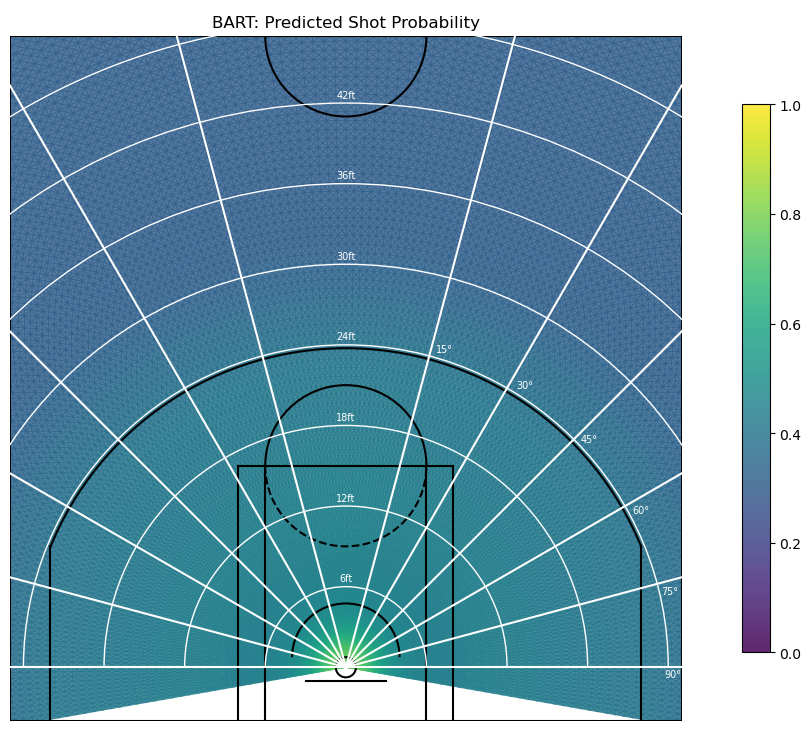

In [34]:
fig, ax = plt.subplots(figsize=(12, 7))
draw_court_on_ax(ax)

dist_court = dist_mesh * 10
angle_rad = np.radians(angle_mesh)

x_right = dist_court*np.sin(angle_rad)
x_left = -dist_court*np.sin(angle_rad)
y_court = dist_court*np.cos(angle_rad)
grid_preds_2d = grid_preds.reshape(100, 100)

for x_court in [x_right, x_left]:
    im = ax.pcolormesh(
        x_court,
        y_court,
        grid_preds_2d,
        cmap='viridis',
        alpha=0.85,
        vmin=0, vmax=1,
        zorder=1,
        shading='gouraud',
    )
plt.colorbar(im, ax=ax, shrink=0.8)

# distance
for dist_ft in range(6, 49, 6):
    dist_units = dist_ft * 10
    ring = Arc((0, 0), width=dist_units*2, height=dist_units*2,
               theta1=0, theta2=180,
               color='white', zorder=3)
    ax.add_patch(ring)
    ax.text(0, dist_units + 2.5, f"{dist_ft}ft",
            fontsize=7, color='white', ha='center', va='bottom',
            zorder=3)

# angle
angle_label_coords = {
    15: (67, 237),
    30: (127, 210),
    45: (175, 170),
    60: (213, 117),
    75: (235, 57),
    90: (237, -5),
}
for angle_deg in range(15, 101, 15):
    angle_rad_line = np.radians(angle_deg)
    for sign in [-1, 1]:
        x_end = sign*500*np.sin(angle_rad_line)
        y_end = 500*np.cos(angle_rad_line)
        ax.plot([0, x_end], [0, y_end],
                color='white', zorder=3)
    
    x_label, y_label = angle_label_coords[angle_deg]
    ax.text(x_label, y_label, f"{angle_deg}°",
            color='white', fontsize=7,
            ha='left', va='center', zorder=3)
    
ax.set_xlim(-250, 250)
ax.set_ylim(-40, 470)
ax.set_title("BART: Predicted Shot Probability")
plt.tight_layout(pad=-0.3)

In [35]:
y_train = train_full['is_made'].values
train_probs = train_full['probs'].values

In [36]:
y_test = test_full['is_made'].values
test_probs = test_full['probs'].values

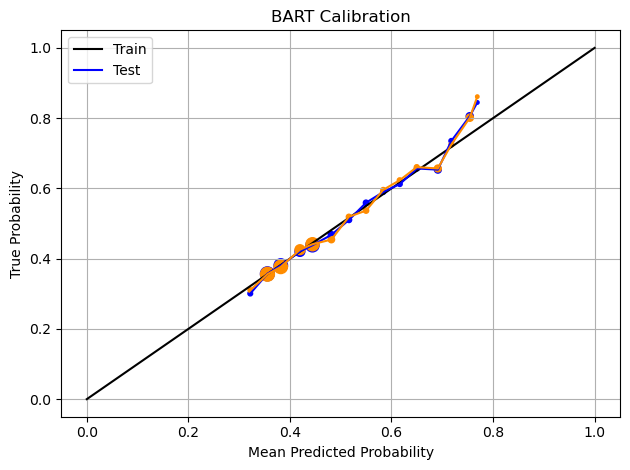

In [37]:
def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze)

plt.plot([0, 1], [0, 1], color='black')
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_test, test_probs, "Test", "darkorange")
plt.title("BART Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Test"], loc="upper left")
plt.grid(True)
plt.tight_layout()

In [7]:
trace_bart = az.from_netcdf("trace_objects/trace_bart.nc")

In [41]:
compute_log_likelihood(model, trace_bart)

Output()

In [ ]:
az.loo(trace_bart, var_name='shot_lkhood')

Computed from 8000 posterior samples and 337511 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -221854.81   149.46
p_loo     1151.56        -
------

Pareto k diagnostic values:
                          Count   Pct.
(-Inf, 0.70]   (good)     337511  100.0%
   (0.70, 1]   (bad)           0    0.0%
   (1, Inf)   (very bad)      0    0.0%

In [43]:
spp = sample_posterior_pred(model, trace_bart)

Sampling: [shot_lkhood]


Output()

<Axes: xlabel='shot_lkhood'>

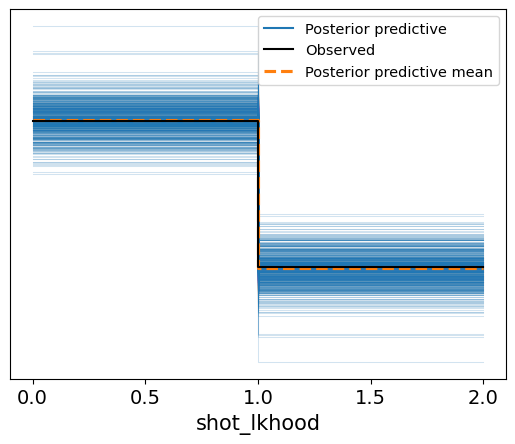

In [45]:
az.plot_ppc(spp, var_names='shot_lkhood', num_pp_samples=500,random_seed=RANDOM_SEED)